# 10 Model Inference Dashboard
# 10.1
Load linear regression model for realtime inference

Load batch data from public S3 for inference data

Load test data to demo as historical data for dashboard demo

In [1]:
# Standard library
import time
from io import BytesIO
from datetime import datetime, timedelta

# Data handling
import pandas as pd
import numpy as np

# AWS / SageMaker
import boto3
import sagemaker
from sagemaker.model import Model
from sagemaker.predictor import Predictor
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import JSONDeserializer

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import pytz

# Sagemaker Env Setup
sess = sagemaker.Session()
role = sagemaker.get_execution_role()
region = boto3.Session().region_name
sm_client = boto3.client("sagemaker")
s3 = boto3.client("s3")

# Bucket and prefix name
bucket = "usdmsaai540-spring2026-team1"
prefix = "CCPP-enery-prediction-linear-regression"

# Key (path inside the bucket)
test_key = f"{prefix}/testing/test_data.csv"
batch_key = f"{prefix}/batch/batch_data.csv"

# S3 path to the model artifact
model_data = f"s3://{bucket}/{prefix}/output/lr-2026-02-18-07-14-00/lr-2026-02-18-07-14-00/output/model.tar.gz"

# ---- Load Test Data ----
test_obj = s3.get_object(Bucket=bucket, Key=test_key)
test_df = pd.read_csv(BytesIO(test_obj["Body"].read()), header=None)
# Last column (ground truth) from test data to be used for historical data demo
ground_truth = test_df.iloc[:, -1]

print("--- Test Data (Target Ground Truth for Historical Data Demo) ---")
display(ground_truth.head())

# ---- Load Batch Data ----
batch_obj = s3.get_object(Bucket=bucket, Key=batch_key)
batch_df = pd.read_csv(BytesIO(batch_obj["Body"].read()), header=None)

# All 10 features will be used for inference, same as used during training.
feature_df = batch_df.iloc[:, 0:10].astype("float32")

print(f"\n---Batch data feature shape for inference (model is expecting 10): {feature_df.shape}---")
display(feature_df.head())

# Convert to numpy for endpoint
features = feature_df.values

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
--- Test Data (Target Ground Truth for Historical Data Demo) ---


0    147.96
1    147.97
2    147.97
3    147.98
4    147.98
Name: 10, dtype: float64


---Batch data feature shape for inference (model is expecting 10): (2955, 10)---


,0,1,2,3,4,5,6,7,8,9
0,13.206,29.559999,1099.800049,4.1605,0.000000,0.0,0.0,1012.900024,0.000000,1015.000000
1,13.181,30.379000,1100.099976,4.7453,747.299988,2.7,7.0,1012.900024,0.000000,1009.700012
2,13.198,29.797001,1100.099976,4.3650,787.900024,2.8,8.0,1015.299988,14.900000,1012.900024
3,13.233,30.344000,1098.800049,5.1058,170.899994,0.6,2.0,1012.500000,23.900000,1012.700012
4,13.246,30.035000,1100.000000,4.7132,683.500000,2.5,7.0,1013.099976,43.599998,1016.000000


# 10.2 -  Host realtime model endpoint from linear learner and trained model artifact

In [2]:
# Set model endpoint name
endpoint_name = "ccpp-lr-realtime-demo"

# Create a Model object for Linear Learner
image_uri = sagemaker.image_uris.retrieve("linear-learner", region)

linear_model = Model(
    image_uri=image_uri,
    model_data=model_data,
    role=role,
    sagemaker_session=sess 
)

print(f"Starting deployment for endpoint: {endpoint_name}...")

# Deploy the model
predictor = linear_model.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large",
    endpoint_name=endpoint_name,
    serializer=CSVSerializer(),
    wait=False 
)

# --- Status Wait Logic ---
status = sm_client.describe_endpoint(EndpointName=endpoint_name)["EndpointStatus"]
print(f"Initial Status: {status}")

while status == "Creating":
    time.sleep(30) 
    status = sm_client.describe_endpoint(EndpointName=endpoint_name)["EndpointStatus"]
    print(f"Status: {status}...")

if status == "InService":
    print(f"\nSuccess! Endpoint {endpoint_name} is live and ready to receive the 4 input features.")
else:
    print(f"\nEndpoint creation failed or is in state: {status}")

Starting deployment for endpoint: ccpp-lr-realtime-demo...
Initial Status: Creating
Status: Creating...
Status: Creating...
Status: Creating...
Status: Creating...
Status: Creating...
Status: Creating...
Status: Creating...
Status: InService...

Success! Endpoint ccpp-lr-realtime-demo is live and ready to receive the 4 input features.


# 10.3 - Run realtime endpoint inference and plot demo dashboard

In [4]:
# Slice data for dashboard demo 
# (10 historical values, 5 future predictions)
past_gt = ground_truth[-15:-5]
future_features = features[-5:]

# Check one row of batch data for inference
print("Sample row being sent:")
print(future_features[0])

Sample row being sent:
[  15.039    36.573  1100.        4.2813    0.        0.        0.
 1033.4      20.9    1038.3   ]


In [5]:
# Test one prediction on the batch data
single_row = ",".join(map(str, future_features[0]))
response = predictor.predict(single_row)
print(response)

{'predictions': [{'score': 173.0679473876953}]}


Success: Endpoint accepted the payload!


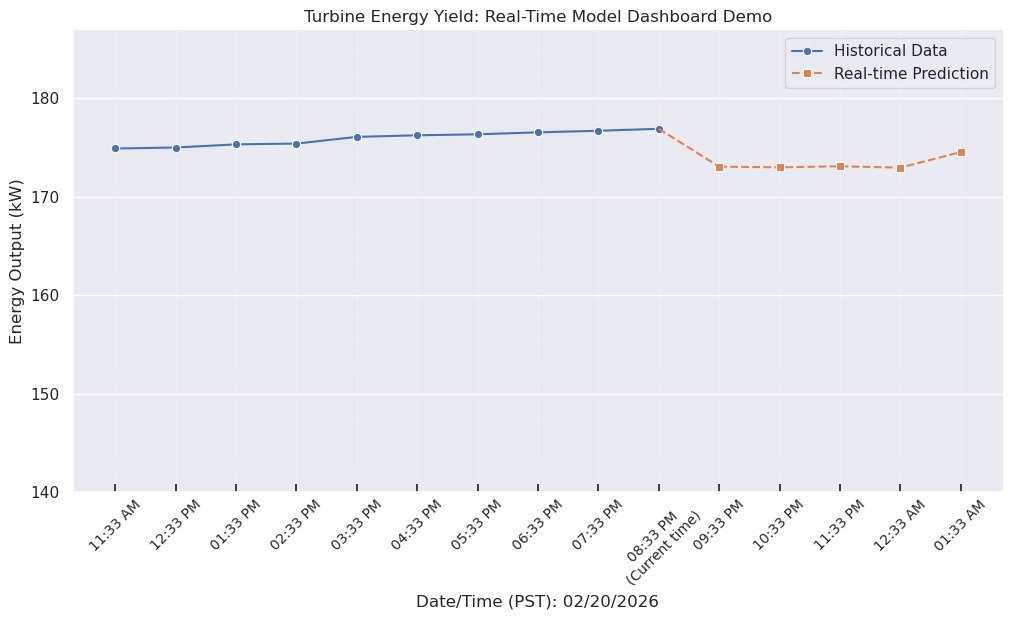

In [10]:
# Try-except block for prediction inference and dashboard plot
# (Try-except block added via ChatGPT to catch feature errors)
try:
    # Create predictions using the predictor
    response = predictor.predict(future_features)
    predictions = [res['score'] for res in response['predictions']]
    print("Success: Endpoint accepted the payload!")

    # Seaborn plot theme for dashboard
    sns.set_theme(style="darkgrid")
    plt.figure(figsize=(12, 6))
    
    # Set timezone to PST 
    # (used for generating datetime objects for plotting)
    pst = pytz.timezone("US/Pacific")
    now = datetime.now(pst)

    # Past timestamps: 1-hr steps into the past, last value = current PST time 
    # (used for plotting historical points)
    x_history = [now - timedelta(hours=len(past_gt)-1 - i) for i in range(len(past_gt))]
    # Format past history and mark last historical timestamp as "Current time" 
    # (used for x-axis labels)
    x_history_fmt = [dt.strftime("%m/%d/%Y %I:%M %p") for dt in x_history]
    x_history_fmt[-1] += " (Current PST time)"

    # Future: 1 hr steps starting from the last historical timestamp
    # (used for plotting predicted points)
    x_prediction = [x_history[-1] + timedelta(hours=i+1) for i in range(len(future_features))]
    # Format future predictions as MM/DD/YYYY HH:MM AM/PM
    # (used for x-axis labels)
    x_prediction_fmt = [dt.strftime("%m/%d/%Y %I:%M %p") for dt in x_prediction]
    
    # Actual past values
    sns.lineplot(
        x=x_history_fmt,
        y=past_gt,
        label="Historical Data",
        marker='o'
    )
    
    # Predicted future values
    sns.lineplot(
        x=x_prediction_fmt,
        y=predictions,
        label="Real-time Prediction",
        marker='s',
        linestyle='--'
    )
    # This connects index 9 (last history) to index 10 (first prediction)
    # Using  'predictions' as the target Y value
    plt.plot(
        [len(past_gt)-1, len(past_gt)],           # X coords: last index of history, first index of pred
        [past_gt.iloc[-1], predictions[0]],       # Y coords: last value of history, first value of pred
        color=sns.color_palette()[1],             # Seaborn color to match predictions
        linestyle='--', 
    )
    plt.title("Turbine Energy Yield: Real-Time Model Dashboard Demo")
    plt.ylabel("Energy Output (kW)")
    plt.xlabel(f"Date/Time (PST): {x_history[0].strftime('%m/%d/%Y')}")
    # Create tick labels with only time
    x_history_ticks = [dt.strftime("%I:%M %p") for dt in x_history]
    x_prediction_ticks = [dt.strftime("%I:%M %p") for dt in x_prediction]
    
    # Add "(Current time)" text to the last historical value
    x_history_ticks[-1] += "\n(Current time)"

    # Combine all ticks
    x_ticks_fmt = x_history_ticks + x_prediction_ticks
    
    plt.xticks(ticks=range(len(x_ticks_fmt)), labels=x_ticks_fmt, rotation=45, fontsize=10)
    
    ax = plt.gca()  # get current axes
    
    # Ensure bottom spine is visible
    ax.spines['bottom'].set_visible(True)
    
    # Draw ticks pointing inwards above the grid
    ax.tick_params(
        axis='x',
        which='major',
        length=6,          # length of tick lines
        direction='in',    # tick direction
        top=False,         # don't draw top ticks
        bottom=True,
        zorder=10          # draw tick above the grid
    )
    # Turn off Seaborn despine on bottom so spine is drawn
    sns.despine(bottom=False, left=False)
    
    # Draw grid behind ticks
    ax.grid(True, axis='x', linestyle='--', alpha=0.3, zorder=0)
    plt.legend()
    # 1. Get the current axes
    ax = plt.gca() 
    
    # 2. Calculate the data max (handling both Series and lists)
    # We use float() or .max() to ensure we get a scalar value
    data_max = max(float(past_gt.max()), max(predictions))
    
    # 3. Set the limits: 140 as the floor, and data_max + 10 as the ceiling
    ax.set_ylim(bottom=140, top=data_max + 10)
    plt.show()S

except Exception as e:
    print(f"ERROR: {e}")
    print("\n--- CRITICAL CHECK ---")
    print(f"The model is rejecting this array: \n{future_features}")

# 10.4 - Delete endpoint after use, shut down kernel

In [37]:
# Delete the endpoint and configuration
predictor.delete_endpoint(delete_endpoint_config=True)
print("Endpoint successfully deleted.")

Endpoint successfully deleted.


In [2]:
%%html

<p><b>Shutting down your kernel for this notebook to release resources.</b></p>
<button class="sm-command-button" data-commandlinker-command="kernelmenu:shutdown" style="display:none;">Shutdown Kernel</button>
        
<script>
try {
    els = document.getElementsByClassName("sm-command-button");
    els[0].click();
}
catch(err) {
    // NoOp
}    
</script>